In [1]:
from pathlib import Path

import numpy as np
import xarray as xr
import pandas as pd

import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator

import cartopy.crs as ccrs
import cmocean.cm as cmo

import xclimate as xclim

In [2]:
## FHIST PPE

variables = [
    "EFLX_LH_TOT_month_1",
    "TLAI_month_1",
    "TSA_month_1",
]

time_slice = slice("1950-01", "2014-12")
year_start = time_slice.start[:4]
year_end = time_slice.stop[:4]
grid = xclim.load_fhist_ppe_grid()

snow_pct_threshold = 100    # maximum allowable percent of snow cover on all months of the average year
nonglc_pct_threshold = 100  # maximum allowable percent of glaciated land for a NON-glaciated gridcell

# Create masks
nonglc_mask = grid.PCT_GLC <= nonglc_pct_threshold
full_mask = nonglc_mask

# snow_mask = fsno_clim_min <= (snow_pct_threshold / 100)
# full_mask = snow_mask & nonglc_mask

fhist = {}
fhist_full = {}
for v in variables:
    print(f"  {v}")
    name = "_".join(v.split("_")[:-2])
    fhist_full[v] = xclim.load_fhist(v, keep_var_only=True)[name].sel(time=time_slice).reindex_like(grid, method="nearest", tolerance=1e-3)
    fhist_full[v] = fhist_full[v].where(full_mask).chunk({'time': -1, 'lat': -1, 'lon': -1})
    fhist_full[v].attrs["masks"] = f"gridcell percent glaciated land <= {nonglc_pct_threshold}"

    fhist[v] = fhist_full[v].sel(time=time_slice)

  EFLX_LH_TOT_month_1
  TLAI_month_1
  TSA_month_1


In [3]:
## LENS2

variables_lens = [
    "EFLX_LH_TOT",
    "TLAI",
    "TSA",
]

grid_lens = xclim.load_cesm2le_grid()
nonglc_mask_lens = grid_lens.PCT_GLC <= nonglc_pct_threshold

lens = {}
for v in variables_lens:
    print(f"  {v}")
    vv = f"{v}_month_1"
    lens[vv] = xclim.load_cesm2le(v, "lnd", "month_1", "h0", keep_var_only=True).sel(time=time_slice)[v].reindex_like(grid_lens, method="nearest", tolerance=1e-3)
    lens[vv] = lens[vv].where(nonglc_mask_lens).chunk({'time': -1, 'lat': -1, 'lon': -1})
    lens[vv].attrs["masks"] = f"gridcell percent glaciated land <= {nonglc_pct_threshold}"

  EFLX_LH_TOT
  TLAI
  TSA


In [4]:
## GOGA2

variables_goga = [
    "EFLX_LH_TOT",
    "TLAI",
    "TSA",
]

grid_goga = xclim.load_goga2_grid()
nonglc_mask_goga = grid_goga.PCT_GLC <= nonglc_pct_threshold

goga = {}
for v in variables_goga:
    print(f"  {v}")
    vv = f"{v}_month_1"
    goga[vv] = xclim.load_goga2(v, "lnd", "month_1", "h0", keep_var_only=True).sel(time=time_slice)[v].reindex_like(grid_lens, method="nearest", tolerance=1e-3)
    goga[vv] = goga[vv].where(nonglc_mask_lens).chunk({'time': -1, 'lat': -1, 'lon': -1})
    goga[vv].attrs["masks"] = f"gridcell percent glaciated land <= {nonglc_pct_threshold}"

  EFLX_LH_TOT
  TLAI
  TSA


In [5]:
## ILAMB

ilamb_gm = {"hfls": {}, "lai": {}}
indir = Path("/glade/work/bbuchovecky/CPL_PPE_CO2/select_parameters/ILAMB_data/processed")
for f in indir.glob("global_mean/*.nc"):
    key = f.stem.split("_")[3]
    var = f.stem.split("_")[0].lower()
    ilamb_gm[var][key] = xr.open_dataset(f)[var+"_"+key]

In [7]:
## CLM6 PPE

varname = "EFLX_LH_TOT"

# Load parameter settings key
clm6_key = pd.read_csv("/glade/campaign/cgd/tss/projects/PPE/ctsm6_oaat/ctsm6_oaat_key.csv")

# Load postprocessed timeseries dataset
in_file = Path("/glade/campaign/cgd/tss/projects/PPE/ctsm6_oaat/postp/ctsm6_oaat_postp_timeseries_1901-2023.nc")
clm6_ts = xr.open_dataset(in_file).sel(year=slice(int(time_slice.start[:4]), int(time_slice.stop[:4])))

# Append key to ds
clm6_ts = clm6_ts.assign_coords(
    key=("member", clm6_key["key"].values),
    param=("member", clm6_key["param"].values),
    minmax=("member", clm6_key["minmax"].values)
)
# clm6_ts = clm6_ts.set_index(ens=["param", "minmax", "key"], append=True)
clm6_et_ts = clm6_ts.EFLX_LH_TOT_global_mean

# ET

In [8]:
v = "EFLX_LH_TOT_month_1"
start_yr = 1995
stop_yr = 2014

fhist_et_ts = fhist_full[v].weighted(grid.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().persist()
fhist_et_tm = fhist_et_ts.sel(year=slice(start_yr, stop_yr)).mean(dim="year").persist()

lens_et_ts = lens[v].weighted(grid_lens.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().persist()
lens_et_tm = lens_et_ts.sel(year=slice(start_yr, stop_yr)).mean(dim="year").persist()

goga_et_ts = goga[v].weighted(grid_goga.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().persist()
goga_et_tm = goga_et_ts.sel(year=slice(start_yr, stop_yr)).mean(dim="year").persist()

clm6_et_tm = clm6_et_ts.sel(year=slice(start_yr, stop_yr)).mean(dim="year").persist()

In [12]:
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14

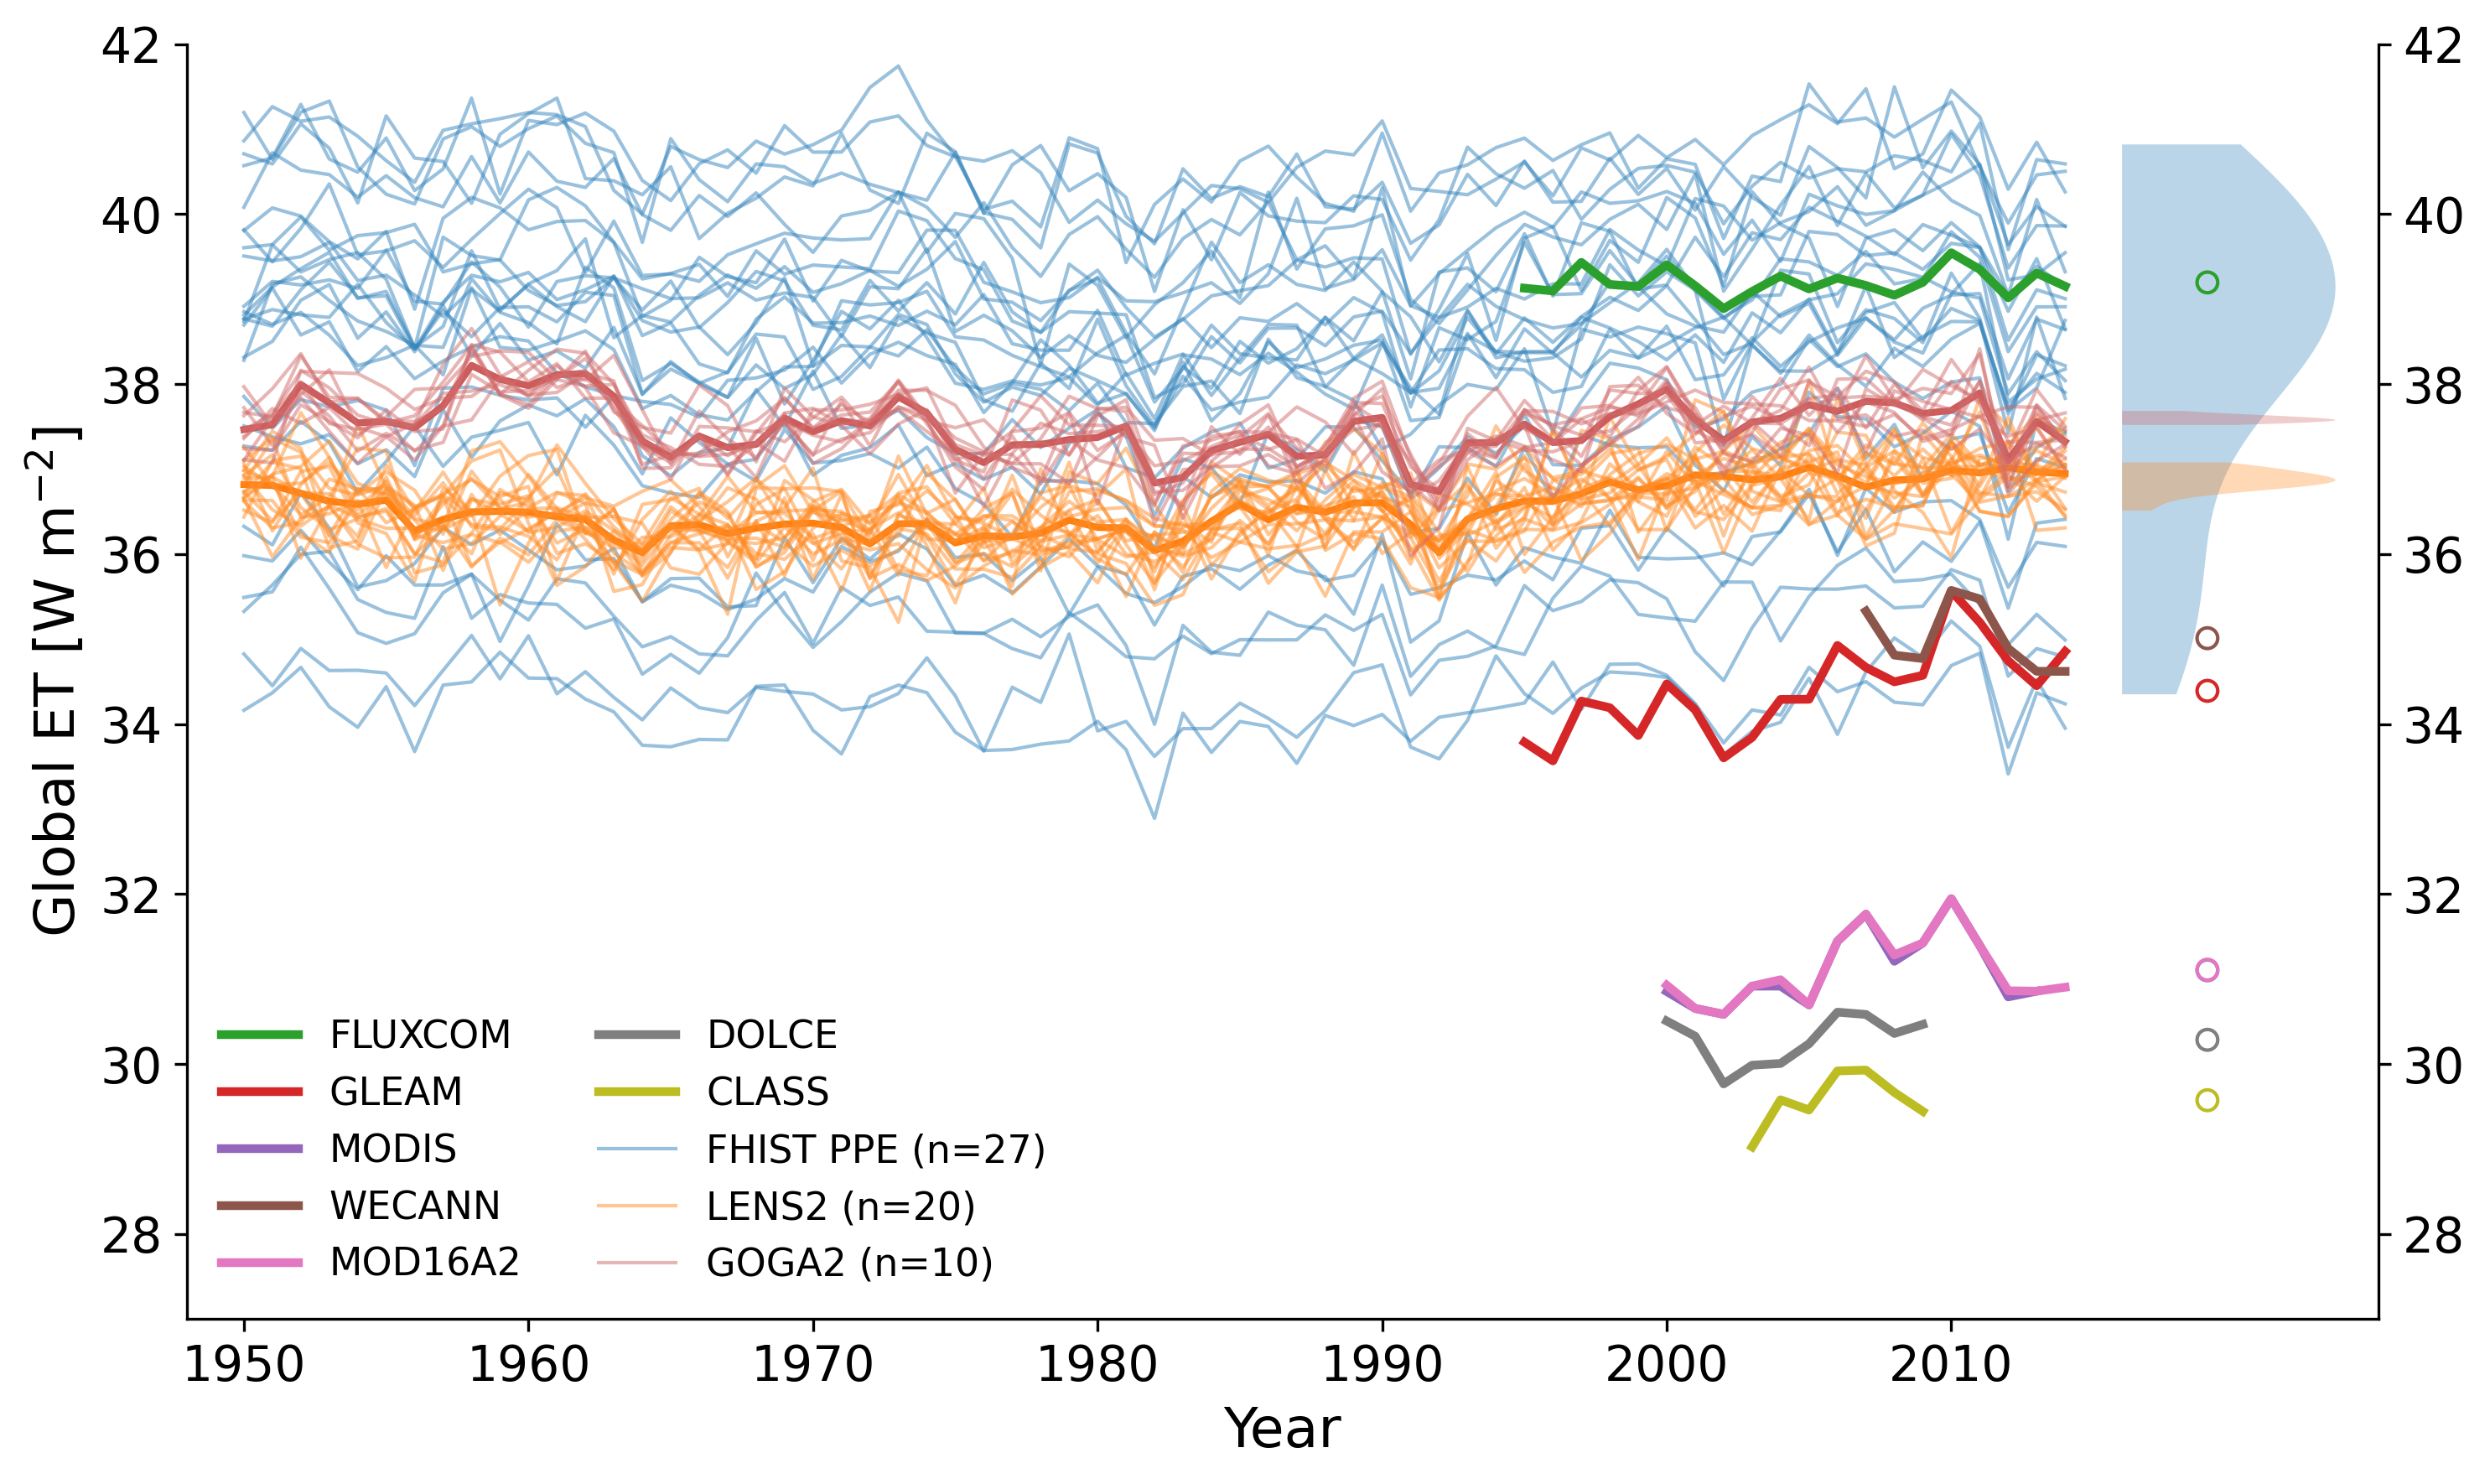

In [17]:
name = "Global ET"
units = "W m$^{-2}$"

fig, ax = plt.subplots(1, 1, figsize=(10, 6), dpi=300)


# Plot ILAMB datasets
cs_ilamb = list(mcolors.TABLEAU_COLORS.keys())[2:]
for i, (key, da) in enumerate(ilamb_gm['hfls'].items()):
    da_trunc = da.sel(year=slice(start_yr, stop_yr))
    ax.plot(da_trunc.year, da_trunc, c=cs_ilamb[i], ls="-", lw=2.5, label=key, zorder=100)
    ax.scatter(stop_yr + 5, da_trunc.mean(dim="year"), marker="o", s=35, edgecolor=cs_ilamb[i], facecolor="none", zorder=100)


# # Plot the timeseries for CLM6 PPE
# for i, e in enumerate(clm6_et_ts.ens):
#     label = None
#     if i == 0:
#         label = f"CLM6 PPE (n={len(clm6_et_ts.ens)})"
#     clm6_et_ts.sel(ens=e).plot(ax=ax, color="silver", alpha=0.3, lw=1, label=label, _labels=False, zorder=0)

# # Plot the violin plot for CLM6 PPE
# vp = xclim.plot._create_violin_plot(
#     ax,
#     clm6_et_tm,
#     stop_yr + 2,
#     "silver",
#     "silver",
# )

# # Highlight the CLM6 PPE default
# # clm6_et_ts.sel(param="default", minmax="max").plot(ax=ax, color="darkgray", lw=2, ls="-", alpha=0.7, label="CLM6 PPE 0", _labels=False, zorder=1)
# ax.scatter(
#     stop_yr + 5,
#     clm6_et_tm.sel(param="default", minmax="max"),
#     s=35,
#     marker="o",
#     color="darkgray",
#     zorder=100,
# )


# Plot FHIST PPE
das = [fhist_et_ts]
das_violin = [fhist_et_tm]
das_labels = ["FHIST PPE"]
_, ax = xclim.plot.plot_ensemble_line(
    das=das,
    das_violin=das_violin,
    das_labels=das_labels,
    ylabel=f"{name} [{units}]",
    plot_dim="year",
    xlabel="Year",
    highlight_member=[None],
    colors=["tab:blue"],
    violin_xrange=None,
    violin_settings={"x": stop_yr + 2},
    add_legend=False,
    ax=ax,
)


# Plot LENS2
lens_et_ts.mean(dim='member').plot(ax=ax, color='tab:orange', alpha=1, lw=2, _labels=False)

das = [lens_et_ts]
das_violin = [lens_et_tm]
das_labels = ["LENS2"]
_, ax = xclim.plot.plot_ensemble_line(
    das=das,
    das_violin=das_violin,
    das_labels=das_labels,
    ylabel=f"{name} [{units}]",
    plot_dim="year",
    xlabel="Year",
    highlight_member=[None],
    colors=["tab:orange"],
    violin_xrange=None,
    violin_settings={"x": stop_yr + 2},
    add_legend=False,
    ax=ax,
)


# Plot GOGA2
goga_et_ts.mean(dim='member').plot(ax=ax, color='indianred', alpha=1, lw=2, _labels=False)

das = [goga_et_ts]
das_violin = [goga_et_tm]
das_labels = ["GOGA2"]
_, ax = xclim.plot.plot_ensemble_line(
    das=das,
    das_violin=das_violin,
    das_labels=das_labels,
    ylabel=f"{name} [{units}]",
    plot_dim="year",
    xlabel="Year",
    highlight_member=[None],
    colors=["indianred"],
    violin_xrange=None,
    violin_settings={"x": stop_yr + 2},
    add_legend=False,
    ax=ax,
)


ax.legend(loc="lower left", ncols=2, fontsize=11, fancybox=False, frameon=False)

ax.set_xlabel("Year")
ax.set_ylabel(f"{name} [{units}]")
ax.set_xlim(1948, 2025)
ax.set_ylim(27, 42)
ax.set_xticks(np.arange(1950, 2011, 10))

ax.yaxis.set_ticks_position("both")
ax.tick_params(axis="y", labelright=True)
ax.spines[['top']].set_visible(False)

plt.tight_layout()

# plt.savefig(f"fig/a.global.lnd.ET.ILAMB-CLM6IHIST-FHIST-LENS2-GOGA2-legend.png", dpi=300, bbox_inches="tight")

/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


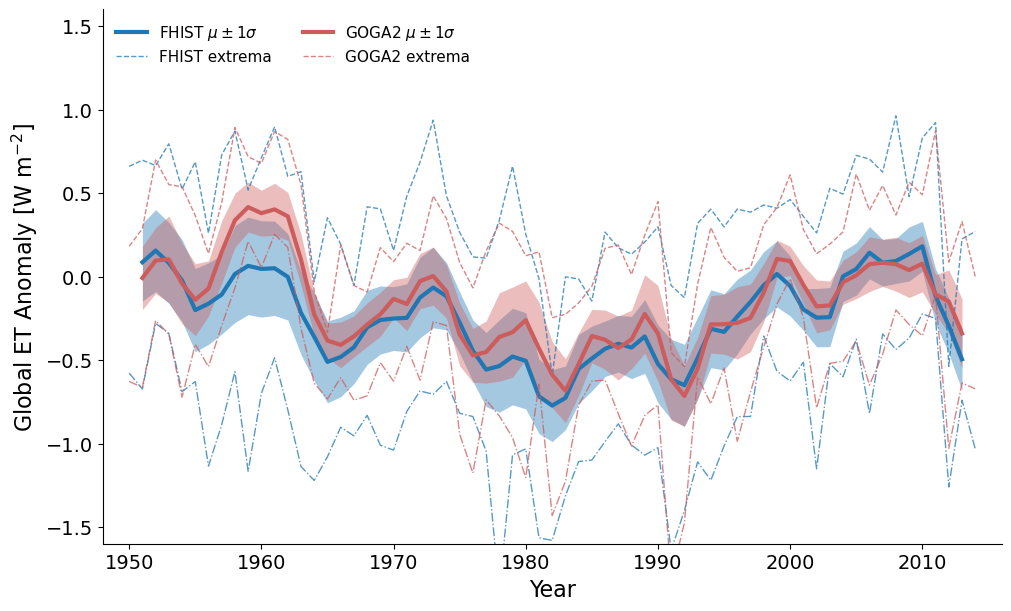

In [26]:
anom_years = slice(2000, 2010)
nsigma = 1

fig, ax = plt.subplots(1, 1, figsize=(10, 6), layout='constrained')
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14


fhist_mn = (fhist_et_ts - fhist_et_ts.sel(year=anom_years).mean(dim='year')).rolling(year=3, center=True).mean('year').mean(dim='member')
fhist_std = (fhist_et_ts - fhist_et_ts.sel(year=anom_years).mean(dim='year')).rolling(year=3, center=True).mean('year').std(dim='member')

lens_mn = (lens_et_ts - lens_et_ts.sel(year=anom_years).mean(dim='year')).rolling(year=3, center=True).mean('year').mean(dim='member')
lens_std = (lens_et_ts - lens_et_ts.sel(year=anom_years).mean(dim='year')).rolling(year=3, center=True).mean('year').std(dim='member')

goga_mn = (goga_et_ts - goga_et_ts.sel(year=anom_years).mean(dim='year')).rolling(year=3, center=True).mean('year').mean(dim='member')
goga_std = (goga_et_ts - goga_et_ts.sel(year=anom_years).mean(dim='year')).rolling(year=3, center=True).mean('year').std(dim='member')

# (fhist_et_ts - fhist_et_ts.mean(dim='year')).plot.line(ax=ax, x='year', color='tab:blue', alpha=0.5, lw=0.8, add_legend=False)
# (lens_et_ts - lens_et_ts.mean(dim='year')).plot.line(ax=ax, x='year', color='tab:orange', alpha=0.5, lw=0.8, add_legend=False)
# (goga_et_ts - goga_et_ts.mean(dim='year')).plot.line(ax=ax, x='year', color='indianred', alpha=0.5, lw=0.8, add_legend=False)

ax.fill_between(fhist_mn.year, fhist_mn-nsigma*fhist_std, fhist_mn+nsigma*fhist_std, color='tab:blue', alpha=0.4, lw=0)
fhist_mn.plot.line(ax=ax, x='year', color='tab:blue', alpha=1, lw=3, add_legend=False, label=f'FHIST $\\mu\\pm{nsigma}\\sigma$')
(fhist_et_ts - fhist_et_ts.sel(year=anom_years).mean(dim='year')).max(dim='member').plot(c='tab:blue', ls="--", lw=1, alpha=0.75, label='FHIST extrema')
(fhist_et_ts - fhist_et_ts.sel(year=anom_years).mean(dim='year')).min(dim='member').plot(c='tab:blue', ls="-.", lw=1, alpha=0.75)

# ax.fill_between(lens_mn.year, lens_mn-nsigma*lens_std, lens_mn+nsigma*lens_std, color='tab:orange', alpha=0.4, lw=0)
# lens_mn.plot.line(ax=ax, x='year', color='tab:orange', alpha=1, lw=3, add_legend=False, label=f'LENS2 $\\mu\\pm{nsigma}\\sigma$')
# (lens_et_ts - lens_et_ts.sel(year=anom_years).mean(dim='year')).max(dim='member').plot(c='tab:orange', ls="--", lw=1, alpha=0.75, label='LENS2 extrema')
# (lens_et_ts - lens_et_ts.sel(year=anom_years).mean(dim='year')).min(dim='member').plot(c='tab:orange', ls="-.", lw=1, alpha=0.75)

ax.fill_between(goga_mn.year, goga_mn-nsigma*goga_std, goga_mn+nsigma*goga_std, color='indianred', alpha=0.4, lw=0)
goga_mn.plot.line(ax=ax, x='year', color='indianred', alpha=1, lw=3, add_legend=False, label=f'GOGA2 $\\mu\\pm{nsigma}\\sigma$')
(goga_et_ts - goga_et_ts.sel(year=anom_years).mean(dim='year')).max(dim='member').plot(c='indianred', ls="--", lw=1, alpha=0.75, label='GOGA2 extrema')
(goga_et_ts - goga_et_ts.sel(year=anom_years).mean(dim='year')).min(dim='member').plot(c='indianred', ls="-.", lw=1, alpha=0.75)

# cs_ilamb = list(mcolors.TABLEAU_COLORS.keys())[2:]
# for i, (key, da) in enumerate(ilamb_gm['hfls'].items()):
#     da_trunc = da.sel(year=slice(start_yr, stop_yr))
#     da_trunc = da_trunc - da_trunc.sel(year=anom_years).mean(dim='year')

#     # ax.plot(da_trunc.year, da_trunc, c=cs_ilamb[i], ls="-", lw=3, label=key, zorder=100)

#     if i == 0:
#         label = "Observations"
#     else:
#         label = None
#     ax.plot(da_trunc.year, da_trunc, c='gray', alpha=0.6, ls="-", lw=3, label=label, zorder=0)

ax.spines[['top', 'right']].set_visible(False)
ax.set_title('')
ax.set_ylim(-1.6, 1.6)
ax.set_xlim(1948, 2016)
ax.set_xlabel('Year')
ax.set_ylabel("Global ET Anomaly [W m$^{-2}$]")
ax.legend(loc='upper left', ncols=2, fontsize=11, fancybox=False, frameon=False)

plt.savefig(f"fig/anom.global.lnd.ET.FHIST-GOGA2-legend.png", dpi=300, bbox_inches="tight")

/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


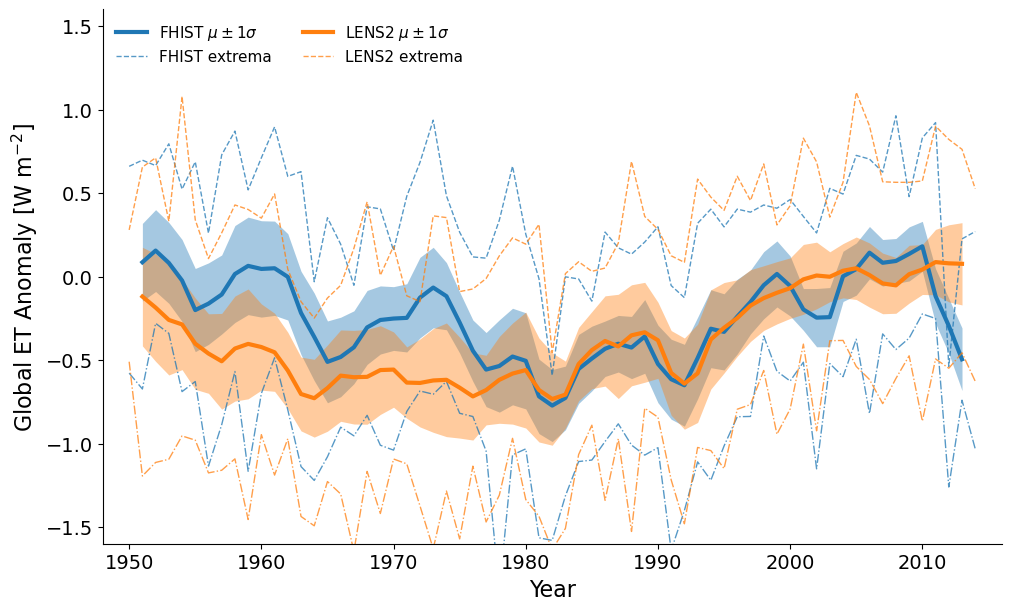

In [27]:
anom_years = slice(2000, 2010)
nsigma = 1

fig, ax = plt.subplots(1, 1, figsize=(10, 6), layout='constrained')
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14


fhist_mn = (fhist_et_ts - fhist_et_ts.sel(year=anom_years).mean(dim='year')).rolling(year=3, center=True).mean('year').mean(dim='member')
fhist_std = (fhist_et_ts - fhist_et_ts.sel(year=anom_years).mean(dim='year')).rolling(year=3, center=True).mean('year').std(dim='member')

lens_mn = (lens_et_ts - lens_et_ts.sel(year=anom_years).mean(dim='year')).rolling(year=3, center=True).mean('year').mean(dim='member')
lens_std = (lens_et_ts - lens_et_ts.sel(year=anom_years).mean(dim='year')).rolling(year=3, center=True).mean('year').std(dim='member')

goga_mn = (goga_et_ts - goga_et_ts.sel(year=anom_years).mean(dim='year')).rolling(year=3, center=True).mean('year').mean(dim='member')
goga_std = (goga_et_ts - goga_et_ts.sel(year=anom_years).mean(dim='year')).rolling(year=3, center=True).mean('year').std(dim='member')

# (fhist_et_ts - fhist_et_ts.mean(dim='year')).plot.line(ax=ax, x='year', color='tab:blue', alpha=0.5, lw=0.8, add_legend=False)
# (lens_et_ts - lens_et_ts.mean(dim='year')).plot.line(ax=ax, x='year', color='tab:orange', alpha=0.5, lw=0.8, add_legend=False)
# (goga_et_ts - goga_et_ts.mean(dim='year')).plot.line(ax=ax, x='year', color='indianred', alpha=0.5, lw=0.8, add_legend=False)

ax.fill_between(fhist_mn.year, fhist_mn-nsigma*fhist_std, fhist_mn+nsigma*fhist_std, color='tab:blue', alpha=0.4, lw=0)
fhist_mn.plot.line(ax=ax, x='year', color='tab:blue', alpha=1, lw=3, add_legend=False, label=f'FHIST $\\mu\\pm{nsigma}\\sigma$')
(fhist_et_ts - fhist_et_ts.sel(year=anom_years).mean(dim='year')).max(dim='member').plot(c='tab:blue', ls="--", lw=1, alpha=0.75, label='FHIST extrema')
(fhist_et_ts - fhist_et_ts.sel(year=anom_years).mean(dim='year')).min(dim='member').plot(c='tab:blue', ls="-.", lw=1, alpha=0.75)

ax.fill_between(lens_mn.year, lens_mn-nsigma*lens_std, lens_mn+nsigma*lens_std, color='tab:orange', alpha=0.4, lw=0)
lens_mn.plot.line(ax=ax, x='year', color='tab:orange', alpha=1, lw=3, add_legend=False, label=f'LENS2 $\\mu\\pm{nsigma}\\sigma$')
(lens_et_ts - lens_et_ts.sel(year=anom_years).mean(dim='year')).max(dim='member').plot(c='tab:orange', ls="--", lw=1, alpha=0.75, label='LENS2 extrema')
(lens_et_ts - lens_et_ts.sel(year=anom_years).mean(dim='year')).min(dim='member').plot(c='tab:orange', ls="-.", lw=1, alpha=0.75)

# ax.fill_between(goga_mn.year, goga_mn-nsigma*goga_std, goga_mn+nsigma*goga_std, color='indianred', alpha=0.4, lw=0)
# goga_mn.plot.line(ax=ax, x='year', color='indianred', alpha=1, lw=3, add_legend=False, label=f'GOGA2 $\\mu\\pm{nsigma}\\sigma$')
# (goga_et_ts - goga_et_ts.sel(year=anom_years).mean(dim='year')).max(dim='member').plot(c='indianred', ls="--", lw=1, alpha=0.75, label='GOGA2 extrema')
# (goga_et_ts - goga_et_ts.sel(year=anom_years).mean(dim='year')).min(dim='member').plot(c='indianred', ls="-.", lw=1, alpha=0.75)

# cs_ilamb = list(mcolors.TABLEAU_COLORS.keys())[2:]
# for i, (key, da) in enumerate(ilamb_gm['hfls'].items()):
#     da_trunc = da.sel(year=slice(start_yr, stop_yr))
#     da_trunc = da_trunc - da_trunc.sel(year=anom_years).mean(dim='year')

#     # ax.plot(da_trunc.year, da_trunc, c=cs_ilamb[i], ls="-", lw=3, label=key, zorder=100)

#     if i == 0:
#         label = "Observations"
#     else:
#         label = None
#     ax.plot(da_trunc.year, da_trunc, c='gray', alpha=0.6, ls="-", lw=3, label=label, zorder=0)

ax.spines[['top', 'right']].set_visible(False)
ax.set_title('')
ax.set_ylim(-1.6, 1.6)
ax.set_xlim(1948, 2016)
ax.set_xlabel('Year')
ax.set_ylabel("Global ET Anomaly [W m$^{-2}$]")
ax.legend(loc='upper left', ncols=2, fontsize=11, fancybox=False, frameon=False)

plt.savefig(f"fig/anom.global.lnd.ET.FHIST-LENS2-legend.png", dpi=300, bbox_inches="tight")

/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


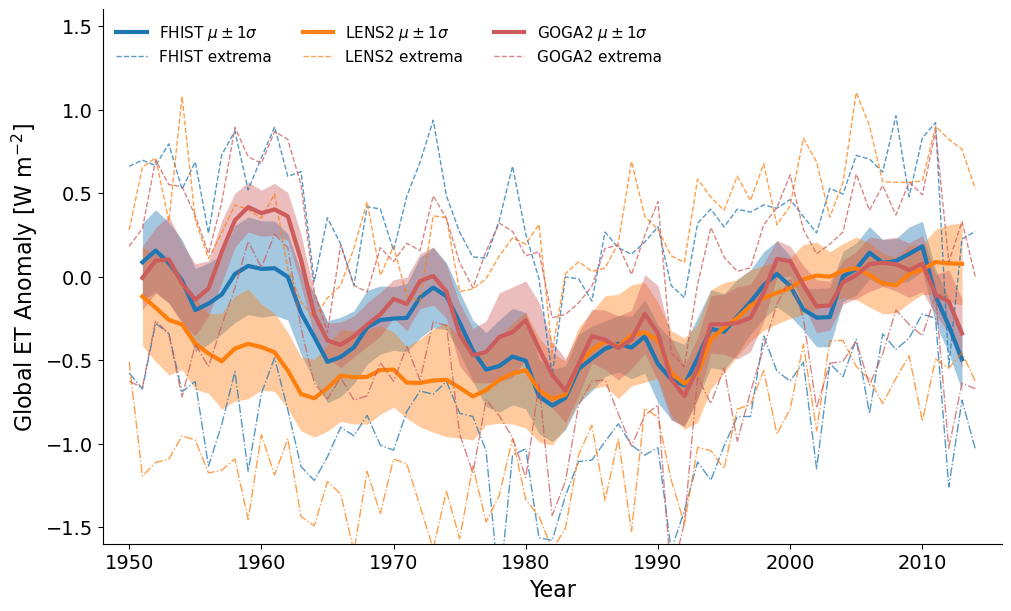

In [29]:
anom_years = slice(2000, 2010)
nsigma = 1

fig, ax = plt.subplots(1, 1, figsize=(10, 6), layout='constrained')
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14


fhist_mn = (fhist_et_ts - fhist_et_ts.sel(year=anom_years).mean(dim='year')).rolling(year=3, center=True).mean('year').mean(dim='member')
fhist_std = (fhist_et_ts - fhist_et_ts.sel(year=anom_years).mean(dim='year')).rolling(year=3, center=True).mean('year').std(dim='member')

lens_mn = (lens_et_ts - lens_et_ts.sel(year=anom_years).mean(dim='year')).rolling(year=3, center=True).mean('year').mean(dim='member')
lens_std = (lens_et_ts - lens_et_ts.sel(year=anom_years).mean(dim='year')).rolling(year=3, center=True).mean('year').std(dim='member')

goga_mn = (goga_et_ts - goga_et_ts.sel(year=anom_years).mean(dim='year')).rolling(year=3, center=True).mean('year').mean(dim='member')
goga_std = (goga_et_ts - goga_et_ts.sel(year=anom_years).mean(dim='year')).rolling(year=3, center=True).mean('year').std(dim='member')

# (fhist_et_ts - fhist_et_ts.mean(dim='year')).plot.line(ax=ax, x='year', color='tab:blue', alpha=0.5, lw=0.8, add_legend=False)
# (lens_et_ts - lens_et_ts.mean(dim='year')).plot.line(ax=ax, x='year', color='tab:orange', alpha=0.5, lw=0.8, add_legend=False)
# (goga_et_ts - goga_et_ts.mean(dim='year')).plot.line(ax=ax, x='year', color='indianred', alpha=0.5, lw=0.8, add_legend=False)

ax.fill_between(fhist_mn.year, fhist_mn-nsigma*fhist_std, fhist_mn+nsigma*fhist_std, color='tab:blue', alpha=0.4, lw=0)
fhist_mn.plot.line(ax=ax, x='year', color='tab:blue', alpha=1, lw=3, add_legend=False, label=f'FHIST $\\mu\\pm{nsigma}\\sigma$')
(fhist_et_ts - fhist_et_ts.sel(year=anom_years).mean(dim='year')).max(dim='member').plot(c='tab:blue', ls="--", lw=1, alpha=0.75, label='FHIST extrema')
(fhist_et_ts - fhist_et_ts.sel(year=anom_years).mean(dim='year')).min(dim='member').plot(c='tab:blue', ls="-.", lw=1, alpha=0.75)

ax.fill_between(lens_mn.year, lens_mn-nsigma*lens_std, lens_mn+nsigma*lens_std, color='tab:orange', alpha=0.4, lw=0)
lens_mn.plot.line(ax=ax, x='year', color='tab:orange', alpha=1, lw=3, add_legend=False, label=f'LENS2 $\\mu\\pm{nsigma}\\sigma$')
(lens_et_ts - lens_et_ts.sel(year=anom_years).mean(dim='year')).max(dim='member').plot(c='tab:orange', ls="--", lw=1, alpha=0.75, label='LENS2 extrema')
(lens_et_ts - lens_et_ts.sel(year=anom_years).mean(dim='year')).min(dim='member').plot(c='tab:orange', ls="-.", lw=1, alpha=0.75)

ax.fill_between(goga_mn.year, goga_mn-nsigma*goga_std, goga_mn+nsigma*goga_std, color='indianred', alpha=0.4, lw=0)
goga_mn.plot.line(ax=ax, x='year', color='indianred', alpha=1, lw=3, add_legend=False, label=f'GOGA2 $\\mu\\pm{nsigma}\\sigma$')
(goga_et_ts - goga_et_ts.sel(year=anom_years).mean(dim='year')).max(dim='member').plot(c='indianred', ls="--", lw=1, alpha=0.75, label='GOGA2 extrema')
(goga_et_ts - goga_et_ts.sel(year=anom_years).mean(dim='year')).min(dim='member').plot(c='indianred', ls="-.", lw=1, alpha=0.75)

# cs_ilamb = list(mcolors.TABLEAU_COLORS.keys())[2:]
# for i, (key, da) in enumerate(ilamb_gm['hfls'].items()):
#     da_trunc = da.sel(year=slice(start_yr, stop_yr))
#     da_trunc = da_trunc - da_trunc.sel(year=anom_years).mean(dim='year')

#     # ax.plot(da_trunc.year, da_trunc, c=cs_ilamb[i], ls="-", lw=3, label=key, zorder=100)

#     if i == 0:
#         label = "Observations"
#     else:
#         label = None
#     ax.plot(da_trunc.year, da_trunc, c='gray', alpha=0.6, ls="-", lw=3, label=label, zorder=0)

ax.spines[['top', 'right']].set_visible(False)
ax.set_title('')
ax.set_ylim(-1.6, 1.6)
ax.set_xlim(1948, 2016)
ax.set_xlabel('Year')
ax.set_ylabel("Global ET Anomaly [W m$^{-2}$]")
ax.legend(loc='upper left', ncols=3, fontsize=11, fancybox=False, frameon=False)

plt.savefig(f"fig/anom.global.lnd.ET.FHIST-GOGA2-LENS2-legend.png", dpi=300, bbox_inches="tight")

# TSA

In [37]:
v = "TSA_month_1"
start_yr = 1995
stop_yr = 2014

fhist_et_ts = (fhist_full[v].weighted(grid.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean() - 273.15).persist()
fhist_et_tm = fhist_et_ts.sel(year=slice(start_yr, stop_yr)).mean(dim="year").persist()

lens_et_ts = (lens[v].weighted(grid_lens.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean() - 273.15).persist()
lens_et_tm = lens_et_ts.sel(year=slice(start_yr, stop_yr)).mean(dim="year").persist()

goga_et_ts = (goga[v].weighted(grid_goga.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean() - 273.15).persist()
goga_et_tm = goga_et_ts.sel(year=slice(start_yr, stop_yr)).mean(dim="year").persist()

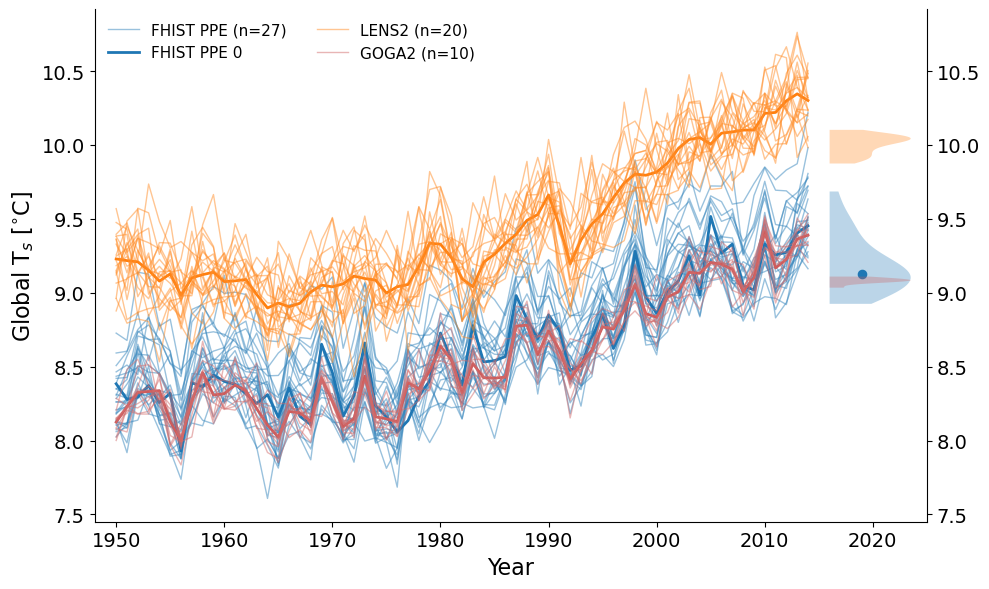

In [41]:
name = "Global T$_s$"
units = "$^{\\circ}$C"

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Plot FHIST PPE
das = [fhist_et_ts]
das_violin = [fhist_et_tm]
das_labels = ["FHIST PPE"]
_, ax = xclim.plot.plot_ensemble_line(
    das=das,
    das_violin=das_violin,
    das_labels=das_labels,
    ylabel=f"{name} [{units}]",
    plot_dim="year",
    xlabel="Year",
    highlight_member=[0],
    colors=["tab:blue"],
    violin_xrange=None,
    violin_settings={"x": stop_yr + 2},
    add_legend=False,
    ax=ax,
)


# Plot LENS2
lens_et_ts.mean(dim='member').plot(ax=ax, color='tab:orange', alpha=1, lw=2, _labels=False)

das = [lens_et_ts]
das_violin = [lens_et_tm]
das_labels = ["LENS2"]
_, ax = xclim.plot.plot_ensemble_line(
    das=das,
    das_violin=das_violin,
    das_labels=das_labels,
    ylabel=f"{name} [{units}]",
    plot_dim="year",
    xlabel="Year",
    highlight_member=[None],
    colors=["tab:orange"],
    violin_xrange=None,
    violin_settings={"x": stop_yr + 2},
    add_legend=False,
    ax=ax,
)


# Plot GOGA2
goga_et_ts.mean(dim='member').plot(ax=ax, color='indianred', alpha=1, lw=2, _labels=False)

das = [goga_et_ts]
das_violin = [goga_et_tm]
das_labels = ["GOGA2"]
_, ax = xclim.plot.plot_ensemble_line(
    das=das,
    das_violin=das_violin,
    das_labels=das_labels,
    ylabel=f"{name} [{units}]",
    plot_dim="year",
    xlabel="Year",
    highlight_member=[None],
    colors=["indianred"],
    violin_xrange=None,
    violin_settings={"x": stop_yr + 2},
    add_legend=False,
    ax=ax,
)


ax.legend(loc="upper left", ncols=2, fontsize=11, fancybox=False, frameon=False)

ax.set_xlabel("Year")
ax.set_ylabel(f"{name} [{units}]")
ax.set_xlim(1948, 2025)
# ax.set_ylim(27, 42)

ax.yaxis.set_ticks_position("both")
ax.tick_params(axis="y", labelright=True)
ax.spines[['top']].set_visible(False)

plt.tight_layout()

plt.savefig(f"fig/a.global.lnd.TSA.ILAMB-CLM6IHIST-FHIST-LENS2-GOGA2-legend.png", dpi=300, bbox_inches="tight")

/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


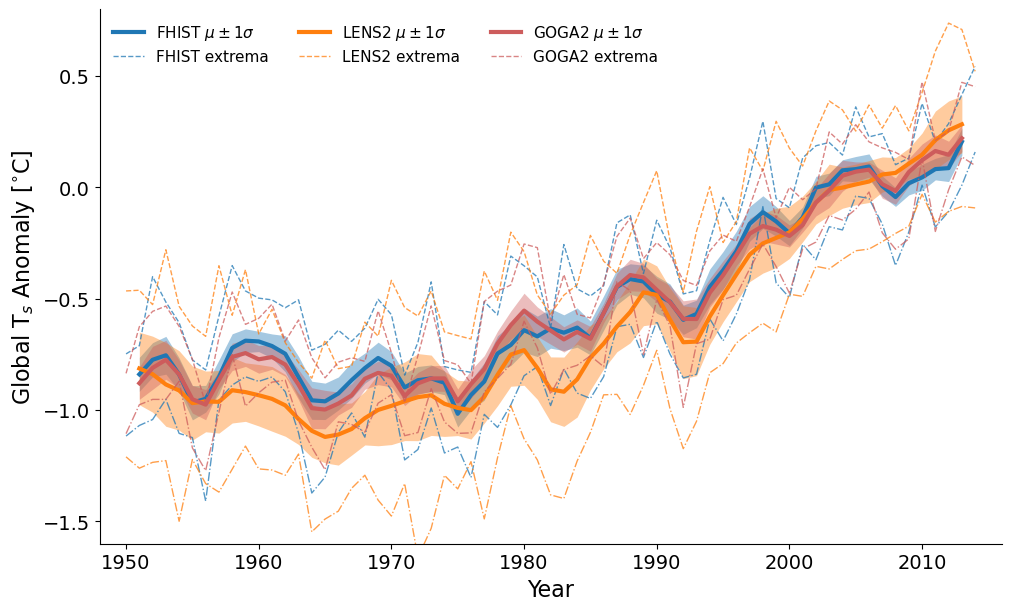

In [42]:
anom_years = slice(2000, 2010)
nsigma = 1

fig, ax = plt.subplots(1, 1, figsize=(10, 6), layout='constrained')
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14


fhist_mn = (fhist_et_ts - fhist_et_ts.sel(year=anom_years).mean(dim='year')).rolling(year=3, center=True).mean('year').mean(dim='member')
fhist_std = (fhist_et_ts - fhist_et_ts.sel(year=anom_years).mean(dim='year')).rolling(year=3, center=True).mean('year').std(dim='member')

lens_mn = (lens_et_ts - lens_et_ts.sel(year=anom_years).mean(dim='year')).rolling(year=3, center=True).mean('year').mean(dim='member')
lens_std = (lens_et_ts - lens_et_ts.sel(year=anom_years).mean(dim='year')).rolling(year=3, center=True).mean('year').std(dim='member')

goga_mn = (goga_et_ts - goga_et_ts.sel(year=anom_years).mean(dim='year')).rolling(year=3, center=True).mean('year').mean(dim='member')
goga_std = (goga_et_ts - goga_et_ts.sel(year=anom_years).mean(dim='year')).rolling(year=3, center=True).mean('year').std(dim='member')


ax.fill_between(fhist_mn.year, fhist_mn-nsigma*fhist_std, fhist_mn+nsigma*fhist_std, color='tab:blue', alpha=0.4, lw=0)
fhist_mn.plot.line(ax=ax, x='year', color='tab:blue', alpha=1, lw=3, add_legend=False, label=f'FHIST $\\mu\\pm{nsigma}\\sigma$')
(fhist_et_ts - fhist_et_ts.sel(year=anom_years).mean(dim='year')).max(dim='member').plot(c='tab:blue', ls="--", lw=1, alpha=0.75, label='FHIST extrema')
(fhist_et_ts - fhist_et_ts.sel(year=anom_years).mean(dim='year')).min(dim='member').plot(c='tab:blue', ls="-.", lw=1, alpha=0.75)

ax.fill_between(lens_mn.year, lens_mn-nsigma*lens_std, lens_mn+nsigma*lens_std, color='tab:orange', alpha=0.4, lw=0)
lens_mn.plot.line(ax=ax, x='year', color='tab:orange', alpha=1, lw=3, add_legend=False, label=f'LENS2 $\\mu\\pm{nsigma}\\sigma$')
(lens_et_ts - lens_et_ts.sel(year=anom_years).mean(dim='year')).max(dim='member').plot(c='tab:orange', ls="--", lw=1, alpha=0.75, label='LENS2 extrema')
(lens_et_ts - lens_et_ts.sel(year=anom_years).mean(dim='year')).min(dim='member').plot(c='tab:orange', ls="-.", lw=1, alpha=0.75)

ax.fill_between(goga_mn.year, goga_mn-nsigma*goga_std, goga_mn+nsigma*goga_std, color='indianred', alpha=0.4, lw=0)
goga_mn.plot.line(ax=ax, x='year', color='indianred', alpha=1, lw=3, add_legend=False, label=f'GOGA2 $\\mu\\pm{nsigma}\\sigma$')
(goga_et_ts - goga_et_ts.sel(year=anom_years).mean(dim='year')).max(dim='member').plot(c='indianred', ls="--", lw=1, alpha=0.75, label='GOGA2 extrema')
(goga_et_ts - goga_et_ts.sel(year=anom_years).mean(dim='year')).min(dim='member').plot(c='indianred', ls="-.", lw=1, alpha=0.75)

ax.spines[['top', 'right']].set_visible(False)
ax.set_title('')
ax.set_ylim(-1.6, 0.8)
ax.set_xlim(1948, 2016)
ax.set_xlabel('Year')
ax.set_ylabel("Global T$_s$ Anomaly [$^{\\circ}$C]")
ax.legend(loc='upper left', ncols=3, fontsize=11, fancybox=False, frameon=False)

plt.savefig(f"fig/anom.global.lnd.TSA.FHIST-GOGA2-LENS2-legend.png", dpi=300, bbox_inches="tight")